# 03 — Forecasting with ARIMA and Prophet

Trains two forecasting approaches on the NGX closing price and compares them on a held-out
test period. **Critical rule for time series:** the train/test split must respect
chronological order — never randomly split, since that would let the model "see the future"
during training.

## Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/ngx_prices_clean.csv", index_col="date", parse_dates=True)
df.head()

,close,open,high,low,volume,change_%,daily_return
date,,,,,,,
2012-01-31,20875.83,20818.56,21009.92,20789.48,NaN,0.70,0.006951
2012-02-01,20790.88,20875.34,20941.03,20790.88,NaN,-0.41,-0.004069
2012-02-02,20822.00,20872.94,20900.58,20785.40,NaN,0.15,0.001497
2012-02-03,20877.64,20822.00,20863.93,20786.35,NaN,0.27,0.002672
2012-02-07,20790.88,20857.90,20903.00,20733.35,NaN,-0.42,-0.004156


## 1. Time-Respecting Train/Test Split

In [21]:
TEST_SIZE_DAYS = 30  # forecast horizon - adjust based on how much test data you have

train = df.iloc[:-TEST_SIZE_DAYS]
test = df.iloc[-TEST_SIZE_DAYS:]

print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train):,} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test):,} days)")

Train: 2012-01-31 to 2026-08-03 (3,589 days)
Test:  2026-08-04 to 2026-09-15 (30 days)


## 2. ARIMA Model

Based on the stationarity testing in notebook 02, the series needed first-differencing
(d=1). Start with a simple ARIMA(1,1,1) as a baseline — adjust p/q based on the ACF/PACF
plots from notebook 02 if you want to try alternatives.

In [22]:
# Reset to integer index for modeling - avoids datetime frequency issues entirely
train_close = train["close"].reset_index(drop=True)

arima_model = ARIMA(train_close, order=(1, 1, 1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 3589
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -28001.689
Date:                Tue, 15 Sep 2026   AIC                          56009.378
Time:                        18:26:04   BIC                          56027.934
Sample:                             0   HQIC                         56015.992
                               - 3589                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5804      0.014     41.581      0.000       0.553       0.608
ma.L1         -0.2947      0.016    -19.000      0.000      -0.325      -0.264
sigma2      3.514e+05   1873.517    187.587      0.0

In [23]:
arima_forecast = arima_fit.forecast(steps=TEST_SIZE_DAYS)
arima_forecast.index = test.index  # reattach real dates now, only for comparison/plotting

arima_mae = mean_absolute_error(test["close"], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test["close"], arima_forecast))
arima_mape = np.mean(np.abs((test["close"] - arima_forecast) / test["close"])) * 100

print(f"ARIMA — MAE: {arima_mae:.2f} | RMSE: {arima_rmse:.2f} | MAPE: {arima_mape:.2f}%")

ARIMA — MAE: 2829.21 | RMSE: 3537.14 | MAPE: 1.17%


## 3. Prophet Model

In [24]:
prophet_train = train.reset_index()[["date", "close"]].rename(columns={"date": "ds", "close": "y"})

prophet_model = Prophet(
    daily_seasonality=False,
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.5,
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=TEST_SIZE_DAYS, freq="B")
prophet_forecast_full = prophet_model.predict(future)

prophet_forecast = prophet_forecast_full.set_index("ds")["yhat"].iloc[-TEST_SIZE_DAYS:]
prophet_forecast = prophet_forecast.reindex(test.index, method="nearest")

18:26:06 - cmdstanpy - INFO - Chain [1] start processing
18:26:11 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
prophet_mae = mean_absolute_error(test["close"], prophet_forecast)
prophet_rmse = np.sqrt(mean_squared_error(test["close"], prophet_forecast))
prophet_mape = np.mean(np.abs((test["close"] - prophet_forecast) / test["close"])) * 100

print(f"Prophet — MAE: {prophet_mae:.2f} | RMSE: {prophet_rmse:.2f} | MAPE: {prophet_mape:.2f}%")

Prophet — MAE: 38877.71 | RMSE: 38966.09 | MAPE: 15.95%


## 4. Compare Forecasts

In [26]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "MAE": [arima_mae, prophet_mae],
    "RMSE": [arima_rmse, prophet_rmse],
    "MAPE (%)": [arima_mape, prophet_mape],
})
results

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,2829.207900,3537.143446,1.170218
1,Prophet,38877.707256,38966.091875,15.953357


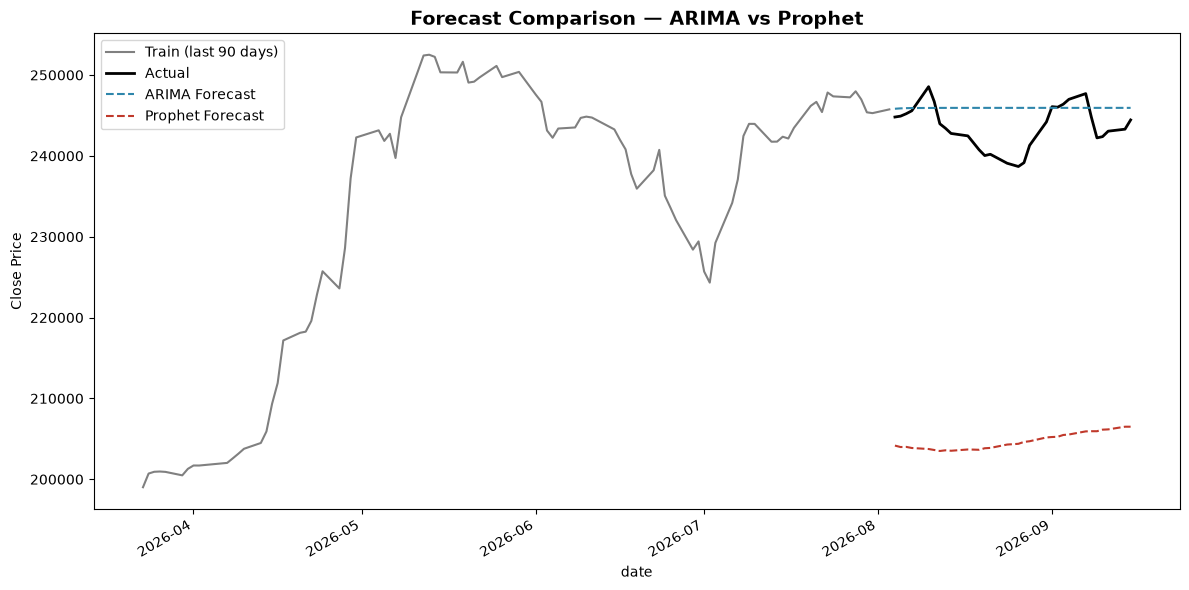

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))
train["close"].iloc[-90:].plot(ax=ax, label="Train (last 90 days)", color="gray")
test["close"].plot(ax=ax, label="Actual", color="black", linewidth=2)
arima_forecast.plot(ax=ax, label="ARIMA Forecast", color="#2E86AB", linestyle="--")
prophet_forecast.plot(ax=ax, label="Prophet Forecast", color="#C0392B", linestyle="--")

ax.set_title("Forecast Comparison — ARIMA vs Prophet", fontsize=14, fontweight="bold")
ax.set_ylabel("Close Price")
ax.legend()
plt.tight_layout()
plt.savefig("../visuals/forecast_comparison.png", dpi=150)
plt.show()

**Takeaway:** ARIMA substantially outperformed Prophet on this test period (MAPE 1.17% vs. 
15.95%). An attempt to improve Prophet by increasing trend flexibility 
(changepoint_prior_scale raised from 0.05 to 0.5) produced only a marginal improvement 
(16.30% → 15.95% MAPE), confirming the gap is structural rather than a tuning issue. The test 
period falls within a period of near-parabolic price growth (2023-2026); ARIMA's 
short-horizon persistence behavior extrapolates recent momentum effectively in this regime, 
while Prophet's changepoint-based trend model is inherently more conservative about 
continuing an accelerating trend, leading to systematic underforecasting.

## 5. Save Forecast Output (for the dashboard)

In [28]:
forecast_output = pd.DataFrame({
    "actual": test["close"],
    "arima_forecast": arima_forecast,
    "prophet_forecast": prophet_forecast,
})
forecast_output.to_csv("../data/forecast_results.csv")
print("Saved forecast comparison to ../data/forecast_results.csv")

Saved forecast comparison to ../data/forecast_results.csv
